# E2-B: a second untouched sample of long, heavily conditioned sentences

**What this experiment asks.** Can a *gold-free* score tell whether an LLM's first-order-logic (FOL) formalization of a sentence is faithful?
The candidate score is **V0 = frozen cross-family consensus `c_score_align`**:

> For a candidate FOL of a sentence, take the formalizations of the same sentence from generators of *other* model families (the peers).
> V0 = 1 − (fraction of those peers that are **z3-equivalent** to the candidate after predicate alignment).
> High V0 means few other families agree with it, which predicts an error.

E2-B is a pre-registered replication on **400 new MALLS sentences with ≥25 words and ≥3 conditions** (L25). Ten frozen generator slots from 9 families
produce 4,000 candidates. Labels come from E2's frozen solver pipeline, and every score was sealed before any label was read.

**Status of the original run: PARTIAL, nothing confirmatory.** The shared API budget ran out mid-run, so the blind panel never finished.
Labels therefore use tier A against the *unaudited* MALLS gold: 48 CORRECT and 334 ERROR, which is below the testability floor of 50 CORRECT.
Every number here is **exploratory**. CORRECT means z3-equivalent to a gold formula that may itself be wrong.

**What this notebook runs.**
1. The original entry point `method.py`, kept as it was written. It is an orchestrator that dispatches pipeline stages (selection, generation, labelling,
   scoring, judges, finalisation, re-derivation). Most stages need paid API calls and the artifact's private virtual environments, so the notebook shows them but does not run them.
2. The `rederive` stage (`src/rederive_headline.py`), inlined cell by cell. It recomputes the headline numbers from the raw sealed label file and score file
   through its own code path: stratified AUROC of V0 against the flash-lite LLM judge, a sentence-cluster bootstrap CI of the difference, placebos that must fail,
   the label-coupling diagnostic (V0 with gold-equivalent peers removed), V0/judge concordance, and rename-invariance flips.
   It runs here on a **100-sentence subset** (`mini_demo_data.json`) instead of all 400 sentences.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# The rederive stage needs only numpy / scipy / scikit-learn (+ matplotlib for the plots).
# All are pre-installed on Colab -> install locally only, at Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import subprocess
import sys
from pathlib import Path

# --- original src/rederive_headline.py imports ---
import json
from collections import defaultdict

import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

# --- notebook-only: plotting / timing ---
import time
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_qck1d05BqxkX/round-5/experiment-12/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
for k, v in data.items():
    if isinstance(v, list):
        print(f"  {k:22s} {len(v):5d} records   (original file: {data['source_files'].get(k, '-')})")

E2-B demo subset: 100 of 400 L25 MALLS sentences (all sentences with a tier-A CORRECT row first), their 10 generator candidates, sealed solver labels, sealed label-free scores (V0, flash-lite disguised), the eval-2 pairwise equivalence matrix and the rename controls. Tables mirror the raw files read by src/rederive_headline.py.
  sentences                100 records   (original file: e2b/sentences_E2B.json)
  candidates_nolabels     1000 records   (original file: e2bsrc/candidates_E2_nolabels.jsonl)
  labels                  1000 records   (original file: e2bsrc/sealed/labels_E2.jsonl)
  scores                  1000 records   (original file: scores/scores_E2B.jsonl)
  pairwise_classes         100 records   (original file: scores/pairwise_classes_E2B.jsonl)
  controls_lf_scores       129 records   (original file: scores/controls_lf_scores_E2B.jsonl)


## Configuration

The re-derivation has three resampling loops. The values in the original script are in the comments.
The demo runs the original values: on 100 sentences the whole stage takes about 10 s. For a fast smoke test, lower them (e.g. 20).

In [5]:
B_BOOT = 2000      # sentence-cluster bootstrap replicates for the V0 - flash-lite delta CI   (original: 2000)
N_PERM = 200       # within-word-bin label permutations for the permutation null            (original: 200)
B_PLACEBO = 1000   # bootstrap replicates for the two placebo CIs                           (original: 1000)
RUN_PIPELINE = False  # True would call method.py's main(): it needs the original workspace, its venvs and an OpenRouter key

## 1. The original entry point: `method.py`

`method.py` maps each pre-registered stage to a command and a working directory, then runs them in order with `subprocess`.
Each stage is a resumable script. Paid stages are cached, so re-running them with the kept `raw/` and cache files re-bills nothing.

| stage | what it does |
|---|---|
| `freeze_check` | verifies the 78 frozen E2 pipeline files by hash |
| `select` | reproduces E2's sentence pool byte for byte, then draws the 400 E2-B sentences by the frozen sha1 order |
| `prereg` | writes the pre-registration (refuses to overwrite the frozen one, so `all` skips it) |
| `generate` | 10 generator slots × 400 sentences = 4,000 candidate FOL formulas |
| `labels` | E2's byte-identical z3 solver labelling + blind panel, in 8 batches of 50 |
| `score` | label-free scores (V0, PT, V1–V5, local features, pairwise matrix), then sealed |
| `judges` | LLM-as-judge baselines (flash-lite, nano, deepseek, frontier) with the byte-identical rubric prompt |
| `finalize` | score seal → label seal → join → analyses → union → outputs |
| `rederive` | independent re-derivation of every headline number (**run below**) |

The only change from the original: `WS = Path(__file__)...` becomes `Path.cwd()`, because a notebook has no `__file__`.
`main()` also takes an explicit argv, because inside Jupyter `sys.argv` holds the kernel's own arguments.

In [6]:
WS = Path.cwd()  # original: Path(__file__).resolve().parent
EPY = str(WS / "e2bsrc/.venv/bin/python")
SPY = str(WS / "exp5src/.venv/bin/python")
STAGES = {
    "freeze_check": [[EPY, "src_e2b/code_freeze_check.py"], "e2bsrc"],
    "select": [[EPY, "src_e2b/select_e2b.py"], "e2bsrc"],
    "prereg": [["python3", "src/prereg_e2b.py"], "."],  # refuses to overwrite the frozen prereg
    "generate": [["bash", "e2bsrc/src_e2b/gen_all.sh"], "."],
    "labels": [["bash", "e2bsrc/src_e2b/run_batches_resume.sh"], "."],
    "score": [["bash", "-c", "bash src/scoring_pipeline.sh && bash src/cpu_chain.sh"], "."],
    "judges": [["bash", "src/judge_resume.sh"], "."],
    "finalize": [["bash", "src/finalize.sh"], "."],
    "rederive": [[SPY, "src/rederive_headline.py"], "."],
}


def run(name: str) -> int:
    cmd, cwd = STAGES[name]
    print(f"=== stage {name}: {' '.join(cmd)} (cwd {cwd})", flush=True)
    return subprocess.run(cmd, cwd=str(WS / cwd)).returncode


def main(argv=None) -> int:  # notebook: explicit argv (original: parse_args() on sys.argv)
    ap = argparse.ArgumentParser()
    ap.add_argument("--stage", default="all", choices=["all", *STAGES])
    a = ap.parse_args(argv)
    names = [n for n in STAGES if n != "prereg"] if a.stage == "all" else [a.stage]
    for n in names:
        rc = run(n)
        if rc != 0:
            print(f"stage {n} failed (rc {rc})")
            return rc
    return 0


# In the original: `if __name__ == "__main__": sys.exit(main())`
if RUN_PIPELINE:
    main(["--stage", "all"])
else:
    print("Pipeline stages (not executed in the demo; `rederive` is inlined below):")
    for n, (cmd, cwd) in STAGES.items():
        print(f"  {n:13s} cwd={cwd:7s} {' '.join(c.replace(str(WS) + '/', '') for c in cmd)}")

Pipeline stages (not executed in the demo; `rederive` is inlined below):
  freeze_check  cwd=e2bsrc  e2bsrc/.venv/bin/python src_e2b/code_freeze_check.py
  select        cwd=e2bsrc  e2bsrc/.venv/bin/python src_e2b/select_e2b.py
  prereg        cwd=.       python3 src/prereg_e2b.py
  generate      cwd=.       bash e2bsrc/src_e2b/gen_all.sh
  labels        cwd=.       bash e2bsrc/src_e2b/run_batches_resume.sh
  score         cwd=.       bash -c bash src/scoring_pipeline.sh && bash src/cpu_chain.sh
  judges        cwd=.       bash src/judge_resume.sh
  finalize      cwd=.       bash src/finalize.sh
  rederive      cwd=.       exp5src/.venv/bin/python src/rederive_headline.py


## 2. The `rederive` stage: helper functions (verbatim)

`src/rederive_headline.py` deliberately uses code paths **different** from the main analysis script, so that agreement between the two is evidence the numbers are right:

- `strat_auc`: AUROC **stratified by word bin**, i.e. the n1·n0-weighted mean of per-bin `sklearn` AUROCs. Bins with only one class are skipped.
  Stratifying stops sentence length from masquerading as signal.
- `boot_delta`: 95% percentile CI of AUROC(a) − AUROC(b), resampling **whole sentences**. The 10 candidates of one sentence share its difficulty, so resampling rows would understate the CI.

`ERROR` is the positive class: a score *predicts an error* when its AUROC is above 0.5.

In [7]:
def jl(p):  # original raw-file reader; the notebook reads the same tables from `data` instead
    return [json.loads(l) for l in Path(p).read_text().splitlines() if l.strip()]


def strat_auc(y, s, h):
    num = den = 0.0
    for b in set(h):
        m = h == b
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += roc_auc_score(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def boot_delta(y, a, b, h, sid, B=2000, seed=12345):
    rng = np.random.default_rng(seed)
    idx_by = defaultdict(list)
    for i, s in enumerate(sid):
        idx_by[s].append(i)
    keys = list(idx_by)
    out = []
    for _ in range(B):
        ix = np.concatenate([idx_by[keys[k]] for k in rng.integers(0, len(keys), len(keys))])
        yy, hh = y[ix], h[ix]
        if len(set(yy)) < 2:
            continue
        d = strat_auc(yy, a[ix], hh) - strat_auc(yy, b[ix], hh)
        if not np.isnan(d):
            out.append(d)
    return [float(np.percentile(out, 2.5)), float(np.percentile(out, 97.5))]

## 3. Join labels and scores

This is the start of the original `main()`. Labels are read straight from the **sealed** label file, which is keyed by E2's row key.
They are joined through the no-label candidate file (row_key → sentence id, generator slot) to the **sealed** label-free scores:
`V0` and `flashlite_disg`, the flash-lite judge shown a *disguised* (nonce-word) version of the sentence and formula, so it cannot draw on memorized MALLS gold.

Only the file reads change (`jl(WS / "...")` → `data["..."]`). The rows are the same records, restricted to the 100 demo sentences.

In [8]:
t_start = time.time()
lab = {r["row_key"]: r for r in data["labels"]}                # jl(WS / "e2bsrc/sealed/labels_E2.jsonl")
nol = data["candidates_nolabels"]                              # jl(WS / "e2bsrc/candidates_E2_nolabels.jsonl")
sc = {r["row_key"]: r for r in data["scores"]}                 # jl(WS / "scores/scores_E2B.jsonl")
wb = {s["sentence_id"]: s["word_bin"] for s in data["sentences"]}  # json.loads((WS / "e2b/sentences_E2B.json").read_text())
rows = []
for n in nol:
    L = lab[n["row_key"]]
    if L["system_class"] != "llm":
        continue
    s = sc[f"{n['sentence_id']}|{n['slot']}"]
    rows.append({"k": f"{n['sentence_id']}|{n['slot']}", "sid": n["sentence_id"], "label": L["label"], "tier": L["label_tier"],
                 "rc": bool(L["reading_choice"]), "V0": s["V0"], "FL": s["flashlite_disg"], "bin": wb[n["sentence_id"]]})
out = {"label_counts_all_llm_rows": {k: sum(r["label"] == k for r in rows) for k in ("CORRECT", "ERROR", "UNRESOLVED", "UNPARSEABLE")}}
print(json.dumps(out, indent=1))

{
 "label_counts_all_llm_rows": {
  "CORRECT": 48,
  "ERROR": 237,
  "UNRESOLVED": 652,
  "UNPARSEABLE": 63
 }
}


## 4. Population R_A_UNAUDITED and V0's stratified AUROC

The evaluable population keeps rows with a definite label (CORRECT/ERROR) from **tier A**: a z3 verdict against the unaudited MALLS gold.
It drops rows where the sentence admits several readings (`reading_choice`). Most rows are `UNRESOLVED`: not equivalent to the gold, but the panel never ran to decide whether they are wrong.
Unparseable outputs are **not dropped silently**. They are counted above, and every metric scores them 1.0 (flagged).

In [9]:
P = [r for r in rows if r["label"] in ("CORRECT", "ERROR") and r["tier"] == "A_unaudited_ref" and not r["rc"]]
out["population_R_A_UNAUDITED"] = {"n": len(P), "ERROR": sum(r["label"] == "ERROR" for r in P), "CORRECT": sum(r["label"] == "CORRECT" for r in P),
                                   "CORRECT_sentences": len({r["sid"] for r in P if r["label"] == "CORRECT"})}
V = [r for r in P if r["V0"] is not None]
y = np.array([r["label"] == "ERROR" for r in V], int)
out["V0_strat_auroc"] = strat_auc(y, np.array([r["V0"] for r in V]), np.array([r["bin"] for r in V]))
print(json.dumps({k: out[k] for k in ("population_R_A_UNAUDITED", "V0_strat_auroc")}, indent=1))

{
 "population_R_A_UNAUDITED": {
  "n": 285,
  "ERROR": 237,
  "CORRECT": 48,
  "CORRECT_sentences": 31
 },
 "V0_strat_auroc": 0.7101058973890816
}


## 5. Paired comparison: V0 vs the flash-lite LLM judge (disguised)

On rows that **both** scores cover, compute stratified AUROC for each, their difference, and a sentence-cluster bootstrap CI (`B_BOOT` replicates).

In [10]:
Q = [r for r in P if r["V0"] is not None and r["FL"] is not None]
yq = np.array([r["label"] == "ERROR" for r in Q], int)
a = np.array([r["V0"] for r in Q])
b = np.array([r["FL"] for r in Q])
h = np.array([r["bin"] for r in Q])
sid = [r["sid"] for r in Q]
d = strat_auc(yq, a, h) - strat_auc(yq, b, h)
out["paired"] = {"n": len(Q), "n_correct": int((yq == 0).sum()), "V0_auroc": strat_auc(yq, a, h), "flashlite_disg_auroc": strat_auc(yq, b, h),
                 "delta": d, "delta_ci": boot_delta(yq, a, b, h, sid, B=B_BOOT)}  # original: default B=2000
print(json.dumps(out["paired"], indent=1))

{
 "n": 199,
 "n_correct": 31,
 "V0_auroc": 0.6782757924490208,
 "flashlite_disg_auroc": 0.47314758732081574,
 "delta": 0.20512820512820507,
 "delta_ci": [
  0.04609219760266712,
  0.3715107897169346
 ]
}


## 6. Placebos that **must fail**

These check that the machinery does not manufacture an effect:
1. **Permuted labels.** Shuffle labels within each word bin (`N_PERM` times). The null delta should centre on 0, and the observed delta gets a two-sided permutation p.
   One permuted-label bootstrap CI must include 0.
2. **Random score.** Replace V0 with uniform noise. Its CI against flash-lite must include 0.

In [11]:
# placebo 1: permutation null of the delta (labels permuted within word bin)
rng = np.random.default_rng(7)
perm = []
for _ in range(N_PERM):  # original: range(200)
    yp = yq.copy()
    for bb in set(h):
        m = np.where(h == bb)[0]
        yp[m] = rng.permutation(yp[m])
    perm.append(strat_auc(yp, a, h) - strat_auc(yp, b, h))
perm = np.array(perm)
out["placebo_permuted_labels"] = {"null_mean": float(perm.mean()), "null_sd": float(perm.std()),
                                  "permutation_p_two_sided": float(np.mean(np.abs(perm) >= abs(d))),
                                  "one_permuted_label_bootstrap_ci": None}
yp = yq.copy()
for bb in set(h):
    m = np.where(h == bb)[0]
    yp[m] = rng.permutation(yp[m])
ci_p = boot_delta(yp, a, b, h, sid, B=B_PLACEBO, seed=99)  # original: B=1000
out["placebo_permuted_labels"]["one_permuted_label_bootstrap_ci"] = ci_p
out["placebo_permuted_labels"]["one_permuted_delta"] = strat_auc(yp, a, h) - strat_auc(yp, b, h)
out["placebo_permuted_labels"]["ci_includes_0_as_required"] = bool(ci_p[0] <= 0 <= ci_p[1])
# placebo 2: random score instead of V0
rs = np.random.default_rng(3).random(len(Q))
ci_r = boot_delta(yq, rs, b, h, sid, B=B_PLACEBO, seed=5)  # original: B=1000
out["placebo_random_score_vs_flashlite"] = {"delta": strat_auc(yq, rs, h) - strat_auc(yq, b, h), "ci": ci_r,
                                            "ci_includes_0_as_required": bool(ci_r[0] <= 0 <= ci_r[1])}
print(json.dumps({k: out[k] for k in ("placebo_permuted_labels", "placebo_random_score_vs_flashlite")}, indent=1))

{
 "placebo_permuted_labels": {
  "null_mean": 0.003245507773066825,
  "null_sd": 0.07672350734855411,
  "permutation_p_two_sided": 0.01,
  "one_permuted_label_bootstrap_ci": [
   -0.14358715337086606,
   0.16247716651311409
  ],
  "one_permuted_delta": 0.013325257419745495,
  "ci_includes_0_as_required": true
 },
 "placebo_random_score_vs_flashlite": {
  "delta": -0.09620432061376949,
  "ci": [
   -0.2618887638300967,
   0.07953523118626726
  ],
  "ci_includes_0_as_required": true
 }
}


## 7. Label-coupling diagnostic: V0 with gold-equivalent peers removed

With gold-equivalence labels, all CORRECT rows of a sentence are equivalent to the gold and so to **each other**. Their V0 is mechanically lower than an ERROR row's,
which inflates V0's AUROC without saying anything about faithfulness.
The diagnostic recomputes V0 from the raw eval-2 pairwise-equivalence matrix (candidates grouped into syntactic-identity *nodes* plus z3-checked equivalent node pairs).
It uses the stage's own agreement logic and **excludes CORRECT peers**. In the full run this dropped V0 from 0.737 to 0.611: about half the apparent advantage is coupling.

In [12]:
# V0_decoupled from raw matrix lines, own agreement logic
labk = {r["k"]: r["label"] for r in rows}
fam = {k: sc[k]["family_vendor"] for k in sc}
dec = {}
for m in data["pairwise_classes"]:  # jl(WS / "scores/pairwise_classes_E2B.jsonl")
    node = {r["row_key"]: nd["node_id"] for nd in m["nodes"] for r in nd["rows"]}
    eq = set()
    for i, j, e, _k, _s in m["pairs"]:
        if e is True:
            eq.add((i, j))
            eq.add((j, i))
    for x in node:
        peers = [p for p in node if p != x and fam[p] != fam[x] and labk.get(p) != "CORRECT"]
        if len(peers) >= 2:
            ag = sum(node[p] == node[x] or (node[x], node[p]) in eq for p in peers)
            dec[x] = 1 - ag / len(peers)
D = [r for r in P if r["k"] in dec]
yd = np.array([r["label"] == "ERROR" for r in D], int)
out["V0_decoupled_strat_auroc"] = strat_auc(yd, np.array([dec[r["k"]] for r in D]), np.array([r["bin"] for r in D]))
print("V0 strat AUROC:", round(out["V0_strat_auroc"], 3), "  V0_decoupled strat AUROC:", round(out["V0_decoupled_strat_auroc"], 3))

V0 strat AUROC: 0.71   V0_decoupled strat AUROC: 0.584


## 8. Label-free checks: concordance with the judge and rename invariance

- **Concordance.** Spearman correlation between V0 and the flash-lite judge on every parseable row both scored. No labels are needed.
- **Rename invariance.** A controlled rewrite that renames predicates (to synonyms, `RENAME_SYN`, or nonce words, `RENAME_NONCE`) and is z3-verified meaning-preserving
  should not change the verdict. A *paired flip* is a control flagged (V0 > 0.5) while its parent is not.
  A nonzero flip rate is the known rename non-invariance of an aligner-based consensus score.

In [13]:
# label-free: concordance and rename flips
both = [s for s in sc.values() if s["parse_ok"] and s["V0"] is not None and s.get("flashlite_disg_status") == "ok"]
out["concordance_spearman_V0_flashlite"] = float(spearmanr([s["V0"] for s in both], [s["flashlite_disg"] for s in both]).statistic)
out["concordance_n"] = len(both)
fl = {}
for c in data["controls_lf_scores"]:  # jl(WS / "scores/controls_lf_scores_E2B.jsonl")
    par = sc[c["parent_row_key"]]["V0"]
    if c["V0_control"] is None or par is None:
        continue
    t = c["control_type"]
    f = fl.setdefault(t, [0, 0])
    f[0] += int(c["V0_control"] > 0.5 and not par > 0.5)
    f[1] += 1
out["rename_paired_flip"] = {t: {"flip": v[0] / v[1], "n": v[1]} for t, v in fl.items()}
Path("rederive_headline.json").write_text(json.dumps(out, indent=1))  # original: WS / "analysis/rederive_headline.json"
print(json.dumps(out, indent=1))
print(f"rederive stage runtime: {time.time() - t_start:.1f} s")

{
 "label_counts_all_llm_rows": {
  "CORRECT": 48,
  "ERROR": 237,
  "UNRESOLVED": 652,
  "UNPARSEABLE": 63
 },
 "population_R_A_UNAUDITED": {
  "n": 285,
  "ERROR": 237,
  "CORRECT": 48,
  "CORRECT_sentences": 31
 },
 "V0_strat_auroc": 0.7101058973890816,
 "paired": {
  "n": 199,
  "n_correct": 31,
  "V0_auroc": 0.6782757924490208,
  "flashlite_disg_auroc": 0.47314758732081574,
  "delta": 0.20512820512820507,
  "delta_ci": [
   0.04609219760266712,
   0.3715107897169346
  ]
 },
 "placebo_permuted_labels": {
  "null_mean": 0.003245507773066825,
  "null_sd": 0.07672350734855411,
  "permutation_p_two_sided": 0.01,
  "one_permuted_label_bootstrap_ci": [
   -0.14358715337086606,
   0.16247716651311409
  ],
  "one_permuted_delta": 0.013325257419745495,
  "ci_includes_0_as_required": true
 },
 "placebo_random_score_vs_flashlite": {
  "delta": -0.09620432061376949,
  "ci": [
   -0.2618887638300967,
   0.07953523118626726
  ],
  "ci_includes_0_as_required": true
 },
 "V0_decoupled_strat_auroc"

## 9. Results

The table compares the demo's re-derivation on 100 sentences with the full 400-sentence values stored in the original `analysis/rederive_headline.json`.
The subset contains **every** sentence with a tier-A CORRECT row, so its CORRECT:ERROR ratio is richer than the full sample's. Expect the direction of each result to match, not the exact values.

In [14]:
FULL = {  # original analysis/rederive_headline.json (all 400 sentences)
    "n (R_A_UNAUDITED)": 382, "CORRECT / ERROR": "48 / 334", "V0 strat AUROC": 0.737, "paired n": 276,
    "V0 AUROC (paired)": 0.704, "flash-lite disg AUROC (paired)": 0.496, "delta V0 - flash-lite": 0.208,
    "delta 95% CI": "[0.060, 0.354]", "permutation p": 0.005, "V0 decoupled AUROC": 0.611,
    "Spearman(V0, flash-lite)": 0.296, "rename flip SYN": 0.088, "rename flip NONCE": 0.107,
}
pp, pr = out["population_R_A_UNAUDITED"], out["paired"]
rf = out["rename_paired_flip"]
DEMO = {
    "n (R_A_UNAUDITED)": pp["n"], "CORRECT / ERROR": f"{pp['CORRECT']} / {pp['ERROR']}", "V0 strat AUROC": out["V0_strat_auroc"],
    "paired n": pr["n"], "V0 AUROC (paired)": pr["V0_auroc"], "flash-lite disg AUROC (paired)": pr["flashlite_disg_auroc"],
    "delta V0 - flash-lite": pr["delta"], "delta 95% CI": f"[{pr['delta_ci'][0]:.3f}, {pr['delta_ci'][1]:.3f}]",
    "permutation p": out["placebo_permuted_labels"]["permutation_p_two_sided"], "V0 decoupled AUROC": out["V0_decoupled_strat_auroc"],
    "Spearman(V0, flash-lite)": out["concordance_spearman_V0_flashlite"],
    "rename flip SYN": rf.get("RENAME_SYN", {}).get("flip", float("nan")), "rename flip NONCE": rf.get("RENAME_NONCE", {}).get("flip", float("nan")),
}
fmt = lambda v: f"{v:.3f}" if isinstance(v, float) else str(v)
print(f"{'quantity':32s} {'demo (100 sent.)':>18s} {'full run (400)':>18s}")
print("-" * 70)
for k in FULL:
    print(f"{k:32s} {fmt(DEMO[k]):>18s} {fmt(FULL[k]):>18s}")
print("\nplacebos fail as required:",
      out["placebo_permuted_labels"]["ci_includes_0_as_required"], "(permuted labels),",
      out["placebo_random_score_vs_flashlite"]["ci_includes_0_as_required"], "(random score)")

quantity                           demo (100 sent.)     full run (400)
----------------------------------------------------------------------
n (R_A_UNAUDITED)                               285                382
CORRECT / ERROR                            48 / 237           48 / 334
V0 strat AUROC                                0.710              0.737
paired n                                        199                276
V0 AUROC (paired)                             0.678              0.704
flash-lite disg AUROC (paired)                0.473              0.496
delta V0 - flash-lite                         0.205              0.208
delta 95% CI                         [0.046, 0.372]     [0.060, 0.354]
permutation p                                 0.010              0.005
V0 decoupled AUROC                            0.584              0.611
Spearman(V0, flash-lite)                      0.290              0.296
rename flip SYN                               0.098              0.088
rename

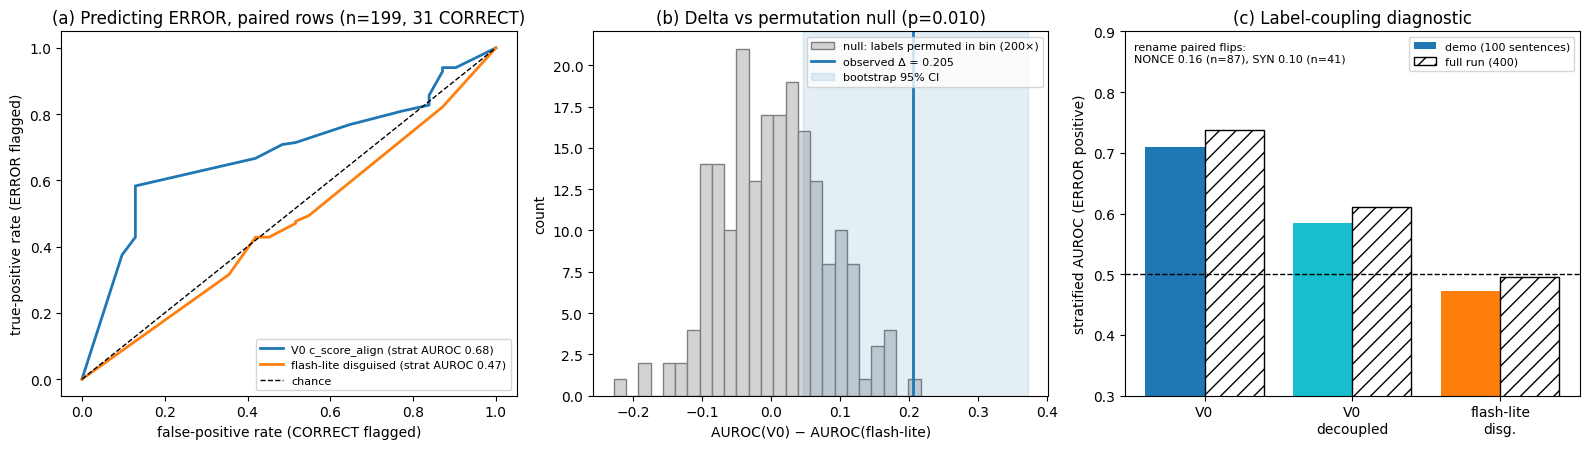

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) ROC curves on the paired rows (ERROR = positive class; pooled over word bins for display)
for sc_arr, name, col in ((a, f"V0 c_score_align (strat AUROC {pr['V0_auroc']:.2f})", "tab:blue"),
                          (b, f"flash-lite disguised (strat AUROC {pr['flashlite_disg_auroc']:.2f})", "tab:orange")):
    fpr, tpr, _ = roc_curve(yq, sc_arr)
    ax[0].plot(fpr, tpr, color=col, lw=2, label=name)
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax[0].set(xlabel="false-positive rate (CORRECT flagged)", ylabel="true-positive rate (ERROR flagged)",
          title=f"(a) Predicting ERROR, paired rows (n={pr['n']}, {pr['n_correct']} CORRECT)")
ax[0].legend(loc="lower right", fontsize=8)

# (b) permutation null of the delta vs the observed delta
ax[1].hist(perm, bins=25, color="lightgray", edgecolor="gray", label=f"null: labels permuted in bin ({len(perm)}×)")
ax[1].axvline(d, color="tab:blue", lw=2, label=f"observed Δ = {d:.3f}")
ax[1].axvspan(*pr["delta_ci"], color="tab:blue", alpha=0.12, label="bootstrap 95% CI")
ax[1].set(xlabel="AUROC(V0) − AUROC(flash-lite)", ylabel="count", title=f"(b) Delta vs permutation null (p={out['placebo_permuted_labels']['permutation_p_two_sided']:.3f})")
ax[1].legend(fontsize=8)

# (c) AUROC summary incl. the label-coupling diagnostic and rename flips
names = ["V0", "V0\ndecoupled", "flash-lite\ndisg."]
vals = [out["V0_strat_auroc"], out["V0_decoupled_strat_auroc"], pr["flashlite_disg_auroc"]]
full_vals = [0.737, 0.611, 0.496]
xx = np.arange(len(names))
ax[2].bar(xx - 0.2, vals, 0.4, color=["tab:blue", "tab:cyan", "tab:orange"], label="demo (100 sentences)")
ax[2].bar(xx + 0.2, full_vals, 0.4, color="none", edgecolor="k", hatch="//", label="full run (400)")
ax[2].axhline(0.5, color="k", ls="--", lw=1)
ax[2].set_xticks(xx, names)
ax[2].set(ylim=(0.3, 0.9), ylabel="stratified AUROC (ERROR positive)", title="(c) Label-coupling diagnostic")
ax[2].legend(fontsize=8, loc="upper right")
flips = ", ".join(f"{t.split('_')[1]} {v['flip']:.2f} (n={v['n']})" for t, v in sorted(rf.items()))
ax[2].text(0.02, 0.97, f"rename paired flips:\n{flips}", transform=ax[2].transAxes, fontsize=8, va="top")
plt.tight_layout()
plt.show()

**How to read this.** V0, the gold-free cross-family consensus score, separates ERROR from CORRECT candidates better than an LLM judge (flash-lite) shown the same content in disguise.
The judge sits near chance on these long, heavily conditioned sentences. Two caveats keep the result exploratory:
1. **Label coupling.** Removing gold-equivalent peers (panel c, "V0 decoupled") shrinks V0's AUROC substantially. Part of the gap comes from CORRECT rows agreeing with one another by construction.
2. **Labels.** CORRECT means "z3-equivalent to the unaudited MALLS gold", with too few CORRECT rows for the pre-registered test (48 < 50). This is not yet a faithfulness test.

V0 needs no API call beyond the peers' generations (about 0.06 s of z3 per candidate). It is not invariant to predicate renaming: renaming only ever *raises* V0, producing roughly 9–11% paired flips.